# White input: the six filters with an uncorrelated regressor

Notebook 04 with `AR_A = 0.0`, so $x_t$ is unit-variance white noise, $R_{xx}$ is the identity and its eigenvalue
spread drops from 346.65 to 1. Metric: misalignment $10\log_{10}\left(\|w_t - h_o\|^2/\|h_o\|^2\right)$, averaged
over realisations.

## 1. Imports

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import lfilter
from scipy.special import gammaln, log_ndtr
from scipy.stats import gennorm
import rir_generator as rir

NOTEBOOK_START = time.time()                   # for the total printed at the very end
print("imports ready")

imports ready


## 2. The scenario

The scenario of notebooks 03 and 04 with the input correlation removed.

* **Room:** $h_o$ = first $M = 128$ samples of the $(5, 10, 6)$ m room of section 7.1, $T_{60} = 200$ ms, 8 kHz. Fixed.
* **Input:** $x_t = u_t$, white, unit variance. **Observation:** $d_t = x_t^{\mathsf T}h_o + \eta_t$.
* **Noise:** generalized Gaussian, $\beta^* = 0.2$, at SNR $= 5$ dB, as in Fig. 3 of the paper.
* **What the filters assume:** Gaussian noise of variance $v_\eta$, or Laplacian of scale $b_\eta = \sqrt{v_\eta/2}$.
* **Run:** $N = 96000$ steps, 12 s at 8 kHz, and $R = 20$ realisations.

In [2]:
M = 128                     # filter length / length of the impulse response
N = 96000                   # steps per run (12 s at 8 kHz, the span of Fig. 3a of the paper)
R = 20                      # independent realisations
WARMUP = 500                # AR samples discarded so the input starts stationary

AR_A = 0.0                  # AR(1) coefficient of the input: 0 makes x_t white, unit variance
SNR_DB = 5.0                # nominal signal-to-noise ratio, as in Fig. 3 of the paper
BETA = 0.2                  # shape of the generalized Gaussian measurement noise
VAR_THETA_0 = 2.0           # initial prior variance on each weight, for the three sKF filters
FS = 8000                   # sampling rate [Hz], the rate of section 7.1 of the draft

# The room of section 7.1 of the draft, simulated with ref. [24] (image method).
ROOM = [5, 10, 6]           # room dimensions [m]
T60 = 0.2                   # reverberation time [s]
C_SOUND = 340               # speed of sound [m/s]
SRC = [1, 2.5, 2]           # source position [m]
MIC = [1, 1.5, 1]           # receiver position [m]

# Generated once and then fixed. Normalised to unit norm: misalignment is scale-invariant
# and SNR_DB is imposed below from P_signal, so the normalisation changes nothing except
# keeping the grids of section 4 on a fixed scale.
ho = rir.generate(c=C_SOUND, fs=FS, r=MIC, s=SRC, L=ROOM,
                  reverberation_time=T60, nsample=M).flatten()
ho = ho/np.linalg.norm(ho)

# Signal power, in closed form: r[k] = AR_A^|k| for a unit-variance AR(1) input.
lags = np.abs(np.subtract.outer(np.arange(M), np.arange(M)))
Rxx = AR_A**lags
P_signal = ho @ Rxx @ ho

var_eta = P_signal/10**(SNR_DB/10)                 # noise variance that gives SNR_DB
b_eta = np.sqrt(var_eta/2)                         # Laplacian scale with that same variance

# Scale of the generalized Gaussian with variance var_eta:
# Var = scale^2 Gamma(3/beta)/Gamma(1/beta).
scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))

eigenvalues = np.linalg.eigvalsh(Rxx)
print(f"signal power    = {P_signal:.6f}")
print(f"eigenvalue spread of Rxx = {eigenvalues.max()/eigenvalues.min():.2f}")
print(f"var_eta         = {var_eta:.4e}   (nominal, at {SNR_DB:.0f} dB SNR)")
print(f"b_eta           = {b_eta:.4e}")
print(f"noise scale     = {scale_gg:.4e}   (generalized Gaussian, beta = {BETA})")
print()
print(f"AR_A = {AR_A}: Rxx is the identity, so P_signal = 1 and the spread is 1.")
print(f"   P_signal is exactly 1 : {np.isclose(P_signal, 1.0)}")
print(f"   Rxx is the identity   : {np.allclose(Rxx, np.eye(M))}")

signal power    = 1.000000
eigenvalue spread of Rxx = 1.00
var_eta         = 3.1623e-01   (nominal, at 5 dB SNR)
b_eta           = 3.9764e-01
noise scale     = 9.3304e-06   (generalized Gaussian, beta = 0.2)

AR_A = 0.0: Rxx is the identity, so P_signal = 1 and the spread is 1.
   P_signal is exactly 1 : True
   Rxx is the identity   : True


`generate_signals(seed)` returns one realisation: the input `x`, the observation `d` and the noise `eta`.

In [3]:
def generate_signals(seed):
    """One realisation: the input, its clean output through ho, and the measurement noise."""
    rng = np.random.default_rng(seed)
    u = np.sqrt(1 - AR_A**2)*rng.standard_normal(N + WARMUP)   # driving noise, unit-variance x
    x = lfilter([1.0], [1.0, -AR_A], u)[WARMUP:]               # x_t = AR_A x_{t-1} + u_t
    y = np.convolve(ho, x)[:N]                                 # clean output, y_t = x_t' ho
    eta = gennorm.rvs(BETA, scale=scale_gg, size=N, random_state=rng)
    return x, y + eta, eta


x, d, eta = generate_signals(0)
print("x:", x.shape, " d:", d.shape)
print(f"noise, first realisation: std {eta.std():.4f}, "
      f"median |eta| {np.median(np.abs(eta)):.5f}, max |eta| {np.abs(eta).max():.4f}")

x: (96000,)  d: (96000,)
noise, first realisation: std 0.5344, median |eta| 0.02090, max |eta| 27.3950


## 3. The six closed forms

The three of notebook 03 (variance recursion on $v$) and the three of notebook 04 (variance fixed at $v$), copied unchanged.
Notation: $e_t = d_t - x_t^{\mathsf T}w_{t-1}$, $\tilde v_t$ predicted variance, $\varepsilon$ process noise, $M$ weights.

### sKF (Gaussian), eqs. (sKF.mean) and (sKF.variance) of the draft

$$\tilde v_t = v_{t-1} + \varepsilon \qquad \alpha_t = \frac{\tilde v_t}{v_\eta + \tilde v_t\|x_t\|^2}$$

$$w_t = w_{t-1} + \alpha_t\,x_t\,e_t \qquad v_t = \tilde v_t\left(1 - \frac{\alpha_t\|x_t\|^2}{M}\right)$$

In [4]:
def shift(new_x_sample, x_window):
    L = len(x_window)
    new_x_window = np.zeros(L)
    new_x_window[0] = new_x_sample
    new_x_window[1:] = x_window[:-1]
    return new_x_window


def sKF_gaussian(n, x, d, w0, parameters):
    """Eqs. (sKF.mean) and (sKF.variance) of the draft: Gaussian noise, variance recursion on v."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    var_eta = parameters["var_eta"]                    # v_eta, observation noise variance
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            gain = v_tilde/(var_eta + v_tilde*power)   # alpha = v_tilde / (v_eta + v_tilde ||x||^2)
            w = w + gain*x_t*e[k]                      # w = w + alpha x_t e_t
            v = v_tilde*(1 - gain*power/M)             # v = v_tilde (1 - alpha ||x||^2 / M)

    return {"w_hist": w_hist, "e": e}


print("sKF (Gaussian) ready")

sKF (Gaussian) ready


### sKF-L (minorized), eqs. (robust.sKF.mean) and (robust.sKF.variance)

The Gaussian filter above with $v_\eta \leftarrow b_\eta|e_t|$:

$$w_t = w_{t-1} + \frac{\tilde v_t\,x_t}{b_\eta|e_t| + \tilde v_t\|x_t\|^2}\,e_t
\qquad v_t = \tilde v_t\left(1 - \frac{1}{M}\frac{\tilde v_t\|x_t\|^2}{b_\eta|e_t| + \tilde v_t\|x_t\|^2}\right)$$

In [5]:
def sKF_L_minorized(n, x, d, w0, parameters):
    """Eqs. (robust.sKF.mean) and (robust.sKF.variance): the sKF above with v_eta -> b_eta |e_t|."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            power = x_t @ x_t                          # ||x_t||^2
            denominator = b_eta*abs(e[k]) + v_tilde*power     # b_eta |e_t| + v_tilde ||x_t||^2
            w = w + x_t*(v_tilde*e[k]/denominator)     # w = w + v_tilde x_t e_t / denominator
            v = v_tilde*(1 - v_tilde*power/(M*denominator))   # v = v_tilde (1 - v_tilde ||x||^2/(M den))

    return {"w_hist": w_hist, "e": e}


print("sKF-L (minorized) ready")

sKF-L (minorized) ready


### sKF-L (exact), eqs. (exact.sKF.mean) and (exact.sKF.variance)

Same prediction. With $\varsigma = \pm 1$, and $\phi$, $\Phi$ the standard normal pdf and cdf:

$$\kappa_\varsigma = \frac{\varsigma e_t - \tilde v_t\|x_t\|^2/b_\eta}{\sqrt{\tilde v_t}\,\|x_t\|}
\qquad \pi_\varsigma = \mathrm{softmax}\!\left(-\varsigma e_t/b_\eta + \log\Phi(\kappa_\varsigma)\right)
\qquad h(\kappa) = \phi(\kappa)/\Phi(\kappa)$$

$$\Lambda = \pi_+ - \pi_- \qquad \Gamma = \pi_+h(\kappa_+) - \pi_-h(\kappa_-) \qquad
P = \pi_+h(\kappa_+) + \pi_-h(\kappa_-) \qquad Q = \pi_+\kappa_+h(\kappa_+) + \pi_-\kappa_-h(\kappa_-)$$

$$w_t = w_{t-1} + \left(\frac{\tilde v_t}{b_\eta}\Lambda - \frac{\sqrt{\tilde v_t}}{\|x_t\|}\Gamma\right)x_t$$

$$D_t = \gamma^2(1-\Lambda^2) - 2\gamma\lambda(P - \Lambda\Gamma) - \lambda^2(Q + \Gamma^2)
\qquad v_t = \tilde v_t + \frac{1}{M}D_t\|x_t\|^2 \qquad \gamma = \frac{\tilde v_t}{b_\eta},\ \lambda = \frac{\sqrt{\tilde v_t}}{\|x_t\|}$$

In [6]:
SIGN = np.array([1.0, -1.0])                           # the two branches, varsigma = +1 and -1


def softmax_two(log_weights):
    """Softmax of the two log weights: subtract the largest, exponentiate, normalise."""
    weights = np.exp(log_weights - log_weights.max())  # largest becomes 1, nothing overflows
    return weights/weights.sum()                       # sums to 1


def sKF_L_exact(n, x, d, w0, parameters):
    """Eqs. (exact.sKF.mean) and (exact.sKF.variance) of the draft: exact marginalization."""
    epsilon = parameters["epsilon"]                    # eps, process noise variance
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    v = parameters["var_theta_0"]                      # v, scalar prior variance on each weight
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            v_tilde = v + epsilon                      # v_tilde = v + eps
            norm_x = np.sqrt(x_t @ x_t)                # ||x_t||
            power = norm_x**2                          # ||x_t||^2

            # The two mixture arguments. Global: no dependence on the weight index m.
            kappa = (SIGN*e[k] - v_tilde*power/b_eta)/(np.sqrt(v_tilde)*norm_x)

            # Mixture weights, in the log domain. Phi(kappa) underflows and e^{2 e / b_eta}
            # overflows, so neither factor may be formed on its own.
            log_Phi = log_ndtr(kappa)                  # log Phi(kappa), accurate in the left tail
            pi = softmax_two(-SIGN*e[k]/b_eta + log_Phi)

            # Inverse Mills ratio h = phi/Phi, also in the log domain.
            log_phi = -0.5*kappa**2 - 0.5*np.log(2*np.pi)
            h = np.exp(log_phi - log_Phi)

            Lambda = np.sum(SIGN*pi)                   # saturating prediction error, in [-1, 1]
            Gamma = np.sum(SIGN*pi*h)
            P = np.sum(pi*h)
            Q = np.sum(pi*kappa*h)

            w = w + (v_tilde*Lambda/b_eta - np.sqrt(v_tilde)*Gamma/norm_x)*x_t

            gamma = v_tilde/b_eta
            lam = np.sqrt(v_tilde)/norm_x
            D = (gamma**2*(1 - Lambda**2)
                 - 2*gamma*lam*(P - Lambda*Gamma)
                 - lam**2*(Q + Gamma**2))
            v = v_tilde + D*power/M                    # v = v_tilde + D ||x_t||^2 / M

    return {"w_hist": w_hist, "e": e}


print("sKF-L (exact) ready")

sKF-L (exact) ready


### fKF (Gaussian), eq. (fKF.mean) of the draft

The sKF above with $\tilde v_t \to v$ and the variance update deleted:

$$w_t = w_{t-1} + \alpha_t\,x_t\,e_t \qquad \alpha_t = \frac{v}{v_\eta + v\|x_t\|^2}$$

$v \to \infty$: NLMS, $\alpha_t = 1/\|x_t\|^2$. $\quad v\|x_t\|^2 \ll v_\eta$: LMS, $\mu = v/v_\eta$.

In [7]:
def fKF_gaussian(n, x, d, w0, parameters):
    """Eq. (fKF.mean) of the draft: the sKF above with its variance fixed at v."""
    v = parameters["v"]                                # v, fixed variance on each weight
    var_eta = parameters["var_eta"]                    # v_eta, observation noise variance
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            power = x_t @ x_t                          # ||x_t||^2
            gain = v/(var_eta + v*power)               # alpha = v / (v_eta + v ||x_t||^2)
            w = w + gain*x_t*e[k]                      # w = w + alpha x_t e_t

    return {"w_hist": w_hist, "e": e}


print("fKF (Gaussian) ready")

fKF (Gaussian) ready


### fKF-L (minorized), eq. (robust.fKF) of the draft

The Gaussian fKF with $v_\eta \leftarrow b_\eta|e_t|$:

$$w_t = w_{t-1} + g_t^{\min}\,x_t\,e_t \qquad g_t^{\min} = \frac{v}{b_\eta|e_t| + v\|x_t\|^2}$$

In [8]:
def fKF_L_minorized(n, x, d, w0, parameters):
    """Eq. (robust.fKF) of the draft: the Gaussian fKF above with v_eta -> b_eta |e_t|."""
    v = parameters["v"]                                # v, fixed variance on each weight
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    gain_hist = np.zeros((n,))                         # gain on x_t e_t at every step

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            power = x_t @ x_t                          # ||x_t||^2
            gain = v/(b_eta*abs(e[k]) + v*power)       # g = v / (b_eta |e_t| + v ||x_t||^2)
            w = w + gain*x_t*e[k]                      # w = w + g x_t e_t
            gain_hist[k] = gain

    return {"w_hist": w_hist, "e": e, "gain_hist": gain_hist}


print("fKF-L (minorized) ready")

fKF-L (minorized) ready


### fKF-L (exact), eq. (exact.fKF) of the draft

The sKF-L above with $\tilde v_t \to v$ and the variance update deleted:

$$\kappa_\varsigma = \frac{\varsigma e_t - v\|x_t\|^2/b_\eta}{\sqrt{v}\,\|x_t\|}
\qquad \Lambda = \pi_+ - \pi_- \qquad \Gamma = \pi_+h(\kappa_+) - \pi_-h(\kappa_-)$$

$$w_t = w_{t-1} + \left(\frac{v}{b_\eta}\Lambda - \frac{\sqrt{v}}{\|x_t\|}\Gamma\right)x_t
\qquad g_t^{\mathrm{ex}} = \frac{1}{e_t}\left(\frac{v}{b_\eta}\Lambda - \frac{\sqrt{v}}{\|x_t\|}\Gamma\right)$$

**Within each family the three differ only in the gain on $x_t e_t$:** Gaussian $\alpha_t$; minorized $g_t^{\min}$, the same with $v_\eta \to b_\eta|e_t|$; exact $g_t^{\mathrm{ex}}$, with $\Lambda \in [-1, 1]$.

In [9]:
def fKF_L_exact(n, x, d, w0, parameters):
    """Eq. (exact.fKF) of the draft: the sKF-L above with its variance fixed at v."""
    v = parameters["v"]                                # v, fixed variance on each weight
    b_eta = parameters["b_eta"]                        # b_eta, Laplacian observation scale
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step
    gain_hist = np.zeros((n,))                         # gain on x_t e_t at every step

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update, as Augusto does

        if k >= M:                                     # Augusto waits for a full window; same here
            norm_x = np.sqrt(x_t @ x_t)                # ||x_t||
            power = norm_x**2                          # ||x_t||^2

            # The two mixture arguments. Global: no dependence on the weight index m.
            kappa = (SIGN*e[k] - v*power/b_eta)/(np.sqrt(v)*norm_x)

            # Mixture weights, in the log domain. Phi(kappa) underflows and e^{2 e / b_eta}
            # overflows, so neither factor may be formed on its own.
            log_Phi = log_ndtr(kappa)                  # log Phi(kappa), accurate in the left tail
            pi = softmax_two(-SIGN*e[k]/b_eta + log_Phi)

            # Inverse Mills ratio h = phi/Phi, also in the log domain.
            log_phi = -0.5*kappa**2 - 0.5*np.log(2*np.pi)
            h = np.exp(log_phi - log_Phi)

            Lambda = np.sum(SIGN*pi)                   # saturating prediction error, in [-1, 1]
            Gamma = np.sum(SIGN*pi*h)

            gain = v*Lambda/b_eta - np.sqrt(v)*Gamma/norm_x
            w = w + gain*x_t                           # w = w + (v L/b_eta - sqrt(v) G/||x||) x_t
            gain_hist[k] = gain/e[k]                   # the coefficient of x_t, over e_t

    return {"w_hist": w_hist, "e": e, "gain_hist": gain_hist}


print("fKF-L (exact) ready")

fKF-L (exact) ready


Three checks: the NLMS limit of the fKF, the minorized filter against Ramiro's implementation, and the
softmax against `scipy.special.logsumexp`.

In [10]:
def NLMS_closed_form(n, x, d, w0):
    """NLMS with unit step, the v -> infinity limit of eq. (fKF.mean). Only for the check below."""
    M = len(w0)                                        # number of weights
    w = w0.copy()                                      # w, current weights, start at w0
    x_t = np.zeros(M)                                  # x_t, window with the last M samples
    w_hist = np.zeros((n, M))                          # weights at every step
    e = np.zeros((n,))                                 # e_t, prediction error at every step

    for k in range(n):
        x_t = shift(x[k], x_t)                         # new sample in, window slides
        e[k] = d[k] - x_t @ w                          # e_t = d_t - x_t' w_{t-1}

        w_hist[k] = w.copy()                           # state BEFORE the update

        if k >= M:                                     # the same wait as the six filters
            w = w + x_t*e[k]/(x_t @ x_t)               # w = w + x_t e_t / ||x_t||^2

    return {"w_hist": w_hist, "e": e}


V_NLMS_CHECK = 1e10                                    # v_eta / (v ||x||^2) ~ 2e-13
w0 = np.zeros(M)                                       # every filter starts from zero

x, d, eta = generate_signals(0)
w_fKF = fKF_gaussian(N, x, d, w0, {"v": V_NLMS_CHECK, "var_eta": var_eta})["w_hist"]
w_NLMS = NLMS_closed_form(N, x, d, w0)["w_hist"]
print(f"fKF at v = {V_NLMS_CHECK:.0e} against NLMS, {N} steps")
print(f"   max |w_fKF - w_NLMS| = {np.abs(w_fKF - w_NLMS).max():.2e}   "
      f"(max |w_NLMS| = {np.abs(w_NLMS).max():.2e})")

fKF at v = 1e+10 against NLMS, 96000 steps
   max |w_fKF - w_NLMS| = 1.78e-13   (max |w_NLMS| = 1.21e+00)


In [11]:
# === RAMIRO: sKF-L minorized (draft eqs. 50 and 51) - copied verbatim, NOT edited ===
# source: https://github.com/Ramirouf/INRS-bayes-adaptive-filters
#         bayes-adaptive-filters.ipynb, cell "Adaptive Filters", commit dbab124
# Kept only for this check: sKF_L_minorized above is the same two lines, with the names
# of the draft and without the (N, L) v_hist that nothing reads.
def sKF_L_algorithm(N, x, d, h0, parameters):
    h = h0
    epsilon = parameters["epsilon"]
    b_eta = parameters["b_eta"]
    v_tilde_0 = parameters["v_tilde_0"]

    L = len(h)
    y = np.zeros((N,))
    e = np.zeros((N,))
    xtemp = np.zeros(L)
    v=v_tilde_0
    h_hist = np.zeros((N, L))
    v_hist = np.zeros((N, L))
    for k in range(0,N):
        xtemp = shift(x[k], xtemp)
        y[k] = h @ xtemp
        e[k] = d[k] - y[k]
        h_hist[k] = h
        v_hist[k] = v

        if k >= L:
            # predict
            v += epsilon
            # update
            norm = xtemp @ xtemp
            s = b_eta * abs(e[k]) + v * norm
            h = h + xtemp * (v * e[k]/s) # not h+= because it would mutate h0
            v = v * (1 - (v * norm) / (L * s))

    return {'h': h_hist, 'y': y, 'e': e, 'v': v_hist}


EPS_CHECK = 1e-6
w_mine = sKF_L_minorized(N, x, d, w0, {"epsilon": EPS_CHECK, "b_eta": b_eta,
                                       "var_theta_0": VAR_THETA_0})["w_hist"]
w_ramiro = sKF_L_algorithm(N, x, d, w0, {"epsilon": EPS_CHECK, "b_eta": b_eta,
                                         "v_tilde_0": VAR_THETA_0})["h"]
print(f"sKF-L (minorized) against Ramiro's implementation, eps = {EPS_CHECK:.0e}, {N} steps")
print(f"   identical bit for bit : {np.array_equal(w_mine, w_ramiro)}")
print(f"   max |difference|      : {np.abs(w_mine - w_ramiro).max():.2e}   "
      f"(max |w| = {np.abs(w_ramiro).max():.2e})")

sKF-L (minorized) against Ramiro's implementation, eps = 1e-06, 96000 steps
   identical bit for bit : True
   max |difference|      : 0.00e+00   (max |w| = 9.08e-01)


In [12]:
# softmax_two replaces scipy.special.logsumexp, which costs 139 us per call on two
# elements and was half the cost of a step of the exact filters. Same softmax, written out.
from scipy.special import logsumexp

rng_check = np.random.default_rng(0)
log_weights = rng_check.uniform(-800, 50, size=(50000, 2))    # the range log_pi actually covers
mine = np.array([softmax_two(row) for row in log_weights])
scipy_version = np.array([np.exp(row - logsumexp(row)) for row in log_weights])
differ = int((mine != scipy_version).any(axis=1).sum())
print(f"softmax_two against scipy.special.logsumexp, {len(log_weights)} random pairs")
print(f"   max |difference| : {np.abs(mine - scipy_version).max():.2e}")
print(f"   differing pairs  : {differ} of {len(log_weights)} (last bit only)")

softmax_two against scipy.special.logsumexp, 50000 random pairs
   max |difference| : 5.68e-14
   differing pairs  : 4149 of 50000 (last bit only)


In [13]:
# Convergence criterion of notebooks 03 and 04, unchanged: floor = mean over the last
# quarter of the run, converged = first step within 3 dB of that floor.
def steady_state(misalignment):
    """Floor in dB, and the first step within 3 dB of it."""
    tail = slice(3*len(misalignment)//4, len(misalignment))
    floor = 10*np.log10(misalignment[tail].mean())
    db = 10*np.log10(misalignment)
    reached = int(np.argmax(db < floor + 3))
    return floor, reached


print("convergence criterion ready")

convergence criterion ready


## 4. Sweeping $\varepsilon$ and $v$

Each value is one point of a curve of floor against time to converge. **The curve is the filter; the parameter says where on it you stand.**

* **Grids:** two points per decade. The sKF filters sweep $\varepsilon$, the fKF filters sweep $v$: different parameters, separate grids.
* **Settled:** $0 <$ steps $\le N/2$ and the third quarter within $0.5$ dB of the floor. A run still descending reads a floor it never reached; those points are dropped and counted.
* **Selected value:** interpolated over the settled points to land on the target, then run once; if out of reach, the deepest settled point.
* $R = 20$, $N = 96000$, same signals for every filter and every parameter value.

In [14]:
TARGET_DB = -20.0         # target floor: each filter's parameter is picked to land here
DRIFT_DB = 0.5              # a settled run's third quarter sits at most this far above its floor
CACHE_PREFIX = "../cache/05_blanca_"

# The three sKF filters sweep epsilon, the three fKF filters sweep v. Different parameters,
# separate grids: two points per decade, one grid per family and noise assumption.
EPS_GRID_SKF_GAUSS = np.logspace(-10, -5, 11)
EPS_GRID_SKF_LAPLACIAN = np.logspace(-10, -5, 11)
V_GRID_FKF_GAUSS = np.logspace(-5, -1, 9)
V_GRID_FKF_LAPLACIAN = np.logspace(-5, -1, 9)

SWEPT_NAME_SKF = "epsilon"
SWEPT_NAME_FKF = "v"

# What each filter is told, besides the parameter being swept.
PARAMETERS_SKF_GAUSS = {"var_eta": var_eta, "var_theta_0": VAR_THETA_0}
PARAMETERS_SKF_L = {"b_eta": b_eta, "var_theta_0": VAR_THETA_0}
PARAMETERS_FKF_GAUSS = {"var_eta": var_eta}
PARAMETERS_FKF_L = {"b_eta": b_eta}

energy_ho = ho @ ho                            # ||ho||^2, the denominator of misalignment

# One set of signals shared by every filter and every parameter, so the comparison is paired.
sweep_signals = []
for seed in range(R):
    x, d, eta = generate_signals(seed)
    sweep_signals.append((x, d))

for label, grid, swept in [("sKF, Gaussian", EPS_GRID_SKF_GAUSS, SWEPT_NAME_SKF),
                           ("sKF-L, minorized and exact", EPS_GRID_SKF_LAPLACIAN, SWEPT_NAME_SKF),
                           ("fKF, Gaussian", V_GRID_FKF_GAUSS, SWEPT_NAME_FKF),
                           ("fKF-L, minorized and exact", V_GRID_FKF_LAPLACIAN, SWEPT_NAME_FKF)]:
    print(f"{label:<28} {len(grid)} values of {swept} over "
          f"{np.log10(grid[-1]/grid[0]):.0f} decades")
    print("   " + "  ".join(f"{value:.1e}" for value in grid))
print()
print(f"target floor: {TARGET_DB:.1f} dB, the value Fig. 3 of the paper pairs with SNR = 5 dB")

sKF, Gaussian                11 values of epsilon over 5 decades
   1.0e-10  3.2e-10  1.0e-09  3.2e-09  1.0e-08  3.2e-08  1.0e-07  3.2e-07  1.0e-06  3.2e-06  1.0e-05
sKF-L, minorized and exact   11 values of epsilon over 5 decades
   1.0e-10  3.2e-10  1.0e-09  3.2e-09  1.0e-08  3.2e-08  1.0e-07  3.2e-07  1.0e-06  3.2e-06  1.0e-05
fKF, Gaussian                9 values of v over 4 decades
   1.0e-05  3.2e-05  1.0e-04  3.2e-04  1.0e-03  3.2e-03  1.0e-02  3.2e-02  1.0e-01
fKF-L, minorized and exact   9 values of v over 4 decades
   1.0e-05  3.2e-05  1.0e-04  3.2e-04  1.0e-03  3.2e-03  1.0e-02  3.2e-02  1.0e-01



target floor: -20.0 dB, the value Fig. 3 of the paper pairs with SNR = 5 dB


The benchmark runs first: one realisation per filter, and the projected cost of the whole sweep.

In [15]:
# Representative values for the benchmark: near each filter's optimum, from the pilot.
BENCHMARK_VALUES = {"sKF (Gaussian)": 1e-8,
                    "sKF-L (minorized)": 1e-7,
                    "sKF-L (exact)": 1e-7,
                    "fKF (Gaussian)": 1e-4,
                    "fKF-L (minorized)": 1e-4,
                    "fKF-L (exact)": 1e-4}

# One realisation per filter with the functions above, before the sweep runs at all.
x, d, eta = generate_signals(0)

benchmark = [("sKF (Gaussian)", sKF_gaussian, PARAMETERS_SKF_GAUSS, EPS_GRID_SKF_GAUSS),
             ("sKF-L (minorized)", sKF_L_minorized, PARAMETERS_SKF_L, EPS_GRID_SKF_LAPLACIAN),
             ("sKF-L (exact)", sKF_L_exact, PARAMETERS_SKF_L, EPS_GRID_SKF_LAPLACIAN),
             ("fKF (Gaussian)", fKF_gaussian, PARAMETERS_FKF_GAUSS, V_GRID_FKF_GAUSS),
             ("fKF-L (minorized)", fKF_L_minorized, PARAMETERS_FKF_L, V_GRID_FKF_LAPLACIAN),
             ("fKF-L (exact)", fKF_L_exact, PARAMETERS_FKF_L, V_GRID_FKF_LAPLACIAN)]

print(f"one realisation of N = {N} steps per filter\n")
print(f"{'filter':<20}{'us/step':>10}{'s/realisation':>15}{'grid':>6}{'sweep [min]':>13}")
projected = 0.0
for name, filter_function, fixed_parameters, grid in benchmark:
    parameters = fixed_parameters.copy()
    parameters[SWEPT_NAME_SKF if name.startswith("sKF") else SWEPT_NAME_FKF] = BENCHMARK_VALUES[name]
    start = time.perf_counter()
    filter_function(N, x, d, w0, parameters)
    seconds = time.perf_counter() - start
    minutes = seconds*R*len(grid)/60                   # its whole grid, at R realisations
    projected += minutes
    print(f"{name:<20}{seconds/N*1e6:>10.1f}{seconds:>15.1f}{len(grid):>6}{minutes:>13.0f}")

print(f"\nprojected sweep, the six filters: {projected/60:.1f} h")
print("   the selected run of each filter adds one more point per filter")

one realisation of N = 96000 steps per filter

filter                 us/step  s/realisation  grid  sweep [min]


sKF (Gaussian)             9.5            0.9    11            3


sKF-L (minorized)          9.7            0.9    11            3


sKF-L (exact)             40.8            3.9    11           14


fKF (Gaussian)             9.6            0.9     9            3


fKF-L (minorized)         10.0            1.0     9            3


fKF-L (exact)             33.7            3.2     9           10

projected sweep, the six filters: 0.6 h
   the selected run of each filter adds one more point per filter


In [16]:
def run_filter(filter_function, parameters, n, signals):
    """Average misalignment curve of one filter at one parameter value, over the given signals."""
    misalignment = np.zeros(n)
    for x, d in signals:
        w_hist = filter_function(n, x[:n], d[:n], w0, parameters)["w_hist"]
        misalignment += ((w_hist - ho)**2).sum(axis=1)/energy_ho
    return misalignment/len(signals)


def is_settled(misalignment):
    """Settled within the run: within 3 dB of the floor by half of it, and no longer descending."""
    n = len(misalignment)
    floor, reached = steady_state(misalignment)
    third_quarter = 10*np.log10(misalignment[n//2:3*n//4].mean())
    # reached = 0: the run never left the 3 dB band around its start, so it never converged either
    return bool(0 < reached <= n/2 and third_quarter - floor <= DRIFT_DB)


def pick_parameter(filter_function, swept_name, grid, floors, settled, fixed_parameters):
    """Interpolate, over the settled points, the value that lands on TARGET_DB; run it once."""
    if not settled.any():
        return {"value": np.nan, "floor": np.nan, "reached": -1,
                "status": "nothing settled", "misalignment": np.full(N, np.nan)}

    settled_values, settled_floors = grid[settled], floors[settled]

    if TARGET_DB > settled_floors.max():
        return {"value": np.nan, "floor": settled_floors.max(), "reached": -1,
                "status": "grid too narrow", "misalignment": np.full(N, np.nan)}

    if TARGET_DB < settled_floors.min():
        value = settled_values[np.argmin(settled_floors)]   # its deepest floor instead
        status = "target not reached"
    else:
        order = np.argsort(settled_floors)
        value = 10**np.interp(TARGET_DB, settled_floors[order], np.log10(settled_values)[order])
        status = "ok"

    parameters = fixed_parameters.copy()
    parameters[swept_name] = value
    misalignment = run_filter(filter_function, parameters, N, sweep_signals)
    floor, reached = steady_state(misalignment)
    return {"value": value, "floor": floor, "reached": reached,
            "status": status, "misalignment": misalignment}


def sweep_filter(name, filter_function, swept_name, grid, fixed_parameters, cache_file):
    """Whole grid plus the selected run, for one filter. Cached in its own file."""
    if os.path.exists(cache_file):
        with np.load(cache_file) as stored:
            if (np.array_equal(stored["grid"], grid)
                    and int(stored["R"]) == R and int(stored["N"]) == N):
                print(f"{name:<20} loaded from {cache_file}")
                return {key: stored[key] for key in stored.files}
        print(f"{name:<20} {cache_file} was computed on another grid, R or N: computing again")

    print(f"{name:<20} computing {len(grid)} grid points at R = {R}, N = {N}")
    start = time.time()
    floors = np.zeros(len(grid))
    steps = np.zeros(len(grid), dtype=int)
    settled = np.zeros(len(grid), dtype=bool)

    for i in range(len(grid)):
        parameters = fixed_parameters.copy()
        parameters[swept_name] = grid[i]               # the one parameter this filter sweeps
        misalignment = run_filter(filter_function, parameters, N, sweep_signals)
        floors[i], steps[i] = steady_state(misalignment)
        settled[i] = is_settled(misalignment)
        print(f"   {swept_name} = {grid[i]:.2e}: floor {floors[i]:+7.2f} dB, {steps[i]:>6} steps, "
              f"{'settled' if settled[i] else 'NOT settled'}   [{time.time() - start:.0f} s]")

    selected = pick_parameter(filter_function, swept_name, grid, floors, settled, fixed_parameters)
    result = {"grid": grid, "floors": floors, "steps": steps, "settled": settled,
              "value": selected["value"], "floor": selected["floor"],
              "reached": selected["reached"], "status": selected["status"],
              "misalignment": selected["misalignment"], "R": R, "N": N}
    np.savez(cache_file, **result)
    print(f"{name:<20} done in {(time.time() - start)/60:.1f} min, saved to {cache_file}")
    return result


print("sweep functions ready")

sweep functions ready


Each filter caches its own sweep in `cache/05_blanca_<filter>.npz`, reused if the grid, $R$ and $N$ match. Delete one file to recompute that filter alone.

In [17]:
resultado_skf_gauss = sweep_filter(
    "sKF (Gaussian)", sKF_gaussian, SWEPT_NAME_SKF, EPS_GRID_SKF_GAUSS,
    PARAMETERS_SKF_GAUSS, CACHE_PREFIX + "skf_gauss.npz")

resultado_skf_min = sweep_filter(
    "sKF-L (minorized)", sKF_L_minorized, SWEPT_NAME_SKF, EPS_GRID_SKF_LAPLACIAN,
    PARAMETERS_SKF_L, CACHE_PREFIX + "skf_min.npz")

resultado_skf_exact = sweep_filter(
    "sKF-L (exact)", sKF_L_exact, SWEPT_NAME_SKF, EPS_GRID_SKF_LAPLACIAN,
    PARAMETERS_SKF_L, CACHE_PREFIX + "skf_exact.npz")

resultado_fkf_gauss = sweep_filter(
    "fKF (Gaussian)", fKF_gaussian, SWEPT_NAME_FKF, V_GRID_FKF_GAUSS,
    PARAMETERS_FKF_GAUSS, CACHE_PREFIX + "fkf_gauss.npz")

resultado_fkf_min = sweep_filter(
    "fKF-L (minorized)", fKF_L_minorized, SWEPT_NAME_FKF, V_GRID_FKF_LAPLACIAN,
    PARAMETERS_FKF_L, CACHE_PREFIX + "fkf_min.npz")

resultado_fkf_exact = sweep_filter(
    "fKF-L (exact)", fKF_L_exact, SWEPT_NAME_FKF, V_GRID_FKF_LAPLACIAN,
    PARAMETERS_FKF_L, CACHE_PREFIX + "fkf_exact.npz")

# Name, result and swept parameter, in the order every table below uses.
RESULTS = [("sKF (Gaussian)", resultado_skf_gauss, SWEPT_NAME_SKF),
           ("sKF-L (minorized)", resultado_skf_min, SWEPT_NAME_SKF),
           ("sKF-L (exact)", resultado_skf_exact, SWEPT_NAME_SKF),
           ("fKF (Gaussian)", resultado_fkf_gauss, SWEPT_NAME_FKF),
           ("fKF-L (minorized)", resultado_fkf_min, SWEPT_NAME_FKF),
           ("fKF-L (exact)", resultado_fkf_exact, SWEPT_NAME_FKF)]

RESULT_SKF_MIN, RESULT_SKF_EXACT = resultado_skf_min, resultado_skf_exact
RESULT_FKF_MIN, RESULT_FKF_EXACT = resultado_fkf_min, resultado_fkf_exact

sKF (Gaussian)       loaded from ../cache/05_blanca_skf_gauss.npz
sKF-L (minorized)    loaded from ../cache/05_blanca_skf_min.npz
sKF-L (exact)        loaded from ../cache/05_blanca_skf_exact.npz
fKF (Gaussian)       loaded from ../cache/05_blanca_fkf_gauss.npz
fKF-L (minorized)    loaded from ../cache/05_blanca_fkf_min.npz
fKF-L (exact)        loaded from ../cache/05_blanca_fkf_exact.npz


Every grid point, then the discarded count. A warning means the deepest settled point sits on a grid edge, where the curve is cut and the grid has to widen.

In [18]:
print(f"{'filter':<20}{'parameter':>11}{'floor [dB]':>12}{'steps':>8}  point")
for name, result, swept_name in RESULTS:
    for value, floor, step, ok in zip(result["grid"], result["floors"],
                                      result["steps"], result["settled"]):
        print(f"{name:<20}{value:>11.1e}{floor:>12.2f}{step:>8}  "
              f"{'settled' if ok else 'not settled'}")

print()
for name, result, swept_name in RESULTS:
    floors, settled = result["floors"], result["settled"]
    print(f"{name:<20} {int(np.sum(~settled))} of {len(floors)} grid points discarded "
          f"as not settled")
    if not settled.any():
        print("   WARNING: no grid point settled")
        continue
    best = np.flatnonzero(settled)[np.argmin(floors[settled])]
    if best in (0, len(floors) - 1):
        print(f"   WARNING: its best point, {swept_name} = {result['grid'][best]:.1e}, "
              f"is on the edge of the grid")

filter                parameter  floor [dB]   steps  point
sKF (Gaussian)          1.0e-10      -33.20   37752  not settled
sKF (Gaussian)          3.2e-10      -31.90   30139  not settled
sKF (Gaussian)          1.0e-09      -29.51   18606  settled
sKF (Gaussian)          3.2e-09      -26.90   11508  settled
sKF (Gaussian)          1.0e-08      -24.33    6372  settled
sKF (Gaussian)          3.2e-08      -21.79    4159  settled
sKF (Gaussian)          1.0e-07      -19.27    2734  settled
sKF (Gaussian)          3.2e-07      -16.78    1724  settled
sKF (Gaussian)          1.0e-06      -14.29    1417  settled
sKF (Gaussian)          3.2e-06      -11.84    1080  settled
sKF (Gaussian)          1.0e-05       -9.50     492  settled
sKF-L (minorized)       1.0e-10      -62.93   64615  not settled
sKF-L (minorized)       3.2e-10      -59.45   36426  settled
sKF-L (minorized)       1.0e-09      -55.38   20512  settled
sKF-L (minorized)       3.2e-09      -51.15   11977  settled
sKF-L (minoriz

## 5. Results

**Figure 1.** Each filter at the value that lands its floor on the target. One row per family, Gaussian apart from the robust pair, because the time scales are decades apart. Dotted, in each curve's colour: its floor, its floor $+\,3$ dB and the instant it crosses that threshold; all three are read off the axes.

In [19]:
t_axis = np.arange(N)/FS                           # steps to seconds, as in Fig. 3 of the paper


def add_ticks(ax, axis, values, colours, decimals, min_gap):
    """Put `values` on the axis as ticks, dropping the automatic ones that would collide.

    Two of the values closer than min_gap keep both ticks: their labels go to opposite
    sides of the tick, so that neither hides the other and both numbers stay readable.
    """
    if axis == "x":
        low, high = ax.get_xlim()
        automatic = ax.get_xticks()
    else:
        low, high = ax.get_ylim()
        automatic = ax.get_yticks()

    kept = []                                      # automatic ticks far enough from the values
    for tick in automatic:
        if not low <= tick <= high:
            continue
        distances = []
        for value in values:
            distances.append(abs(tick - value))
        if min(distances) >= min_gap:
            kept.append(tick)

    positions = sorted(kept + list(values))
    labels = []
    for position in positions:
        labels.append(f"{position:.{decimals}f}")

    if axis == "x":
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        texts = ax.get_xticklabels()
    else:
        ax.set_yticks(positions)
        ax.set_yticklabels(labels, fontsize=8)
        texts = ax.get_yticklabels()

    # Two added values too close to each other: their labels go to opposite sides.
    nudge = {}
    order = np.argsort(values)
    for rank in range(1, len(order)):
        lower, upper = values[order[rank - 1]], values[order[rank]]
        if abs(upper - lower) < min_gap:
            nudge[lower] = "top" if axis == "y" else "right"
            nudge[upper] = "bottom" if axis == "y" else "left"

    # Each added tick takes the colour of the curve it belongs to.
    for position, text in zip(positions, texts):
        for value, colour in zip(values, colours):
            if position == value:
                text.set_color(colour)
                if value in nudge and axis == "y":
                    text.set_verticalalignment(nudge[value])
                elif value in nudge:
                    text.set_horizontalalignment(nudge[value])


def readable_ticks(values, gap, decimals, log=False):
    """Ticks at every value; a label is blanked when it would print on top of the previous one,
    or when it would round to the same text as the label before it."""
    values = np.unique(values)
    positions = np.log10(values) if log else values
    labels, last_position, last_label = [], -np.inf, ""
    for value, position in zip(values, positions):
        label = f"{value:.{decimals}f}"
        if position - last_position >= gap and label != last_label:
            labels.append(label)
            last_position, last_label = position, label
        else:
            labels.append("")
    return values, labels


print("tick helpers ready")

tick helpers ready


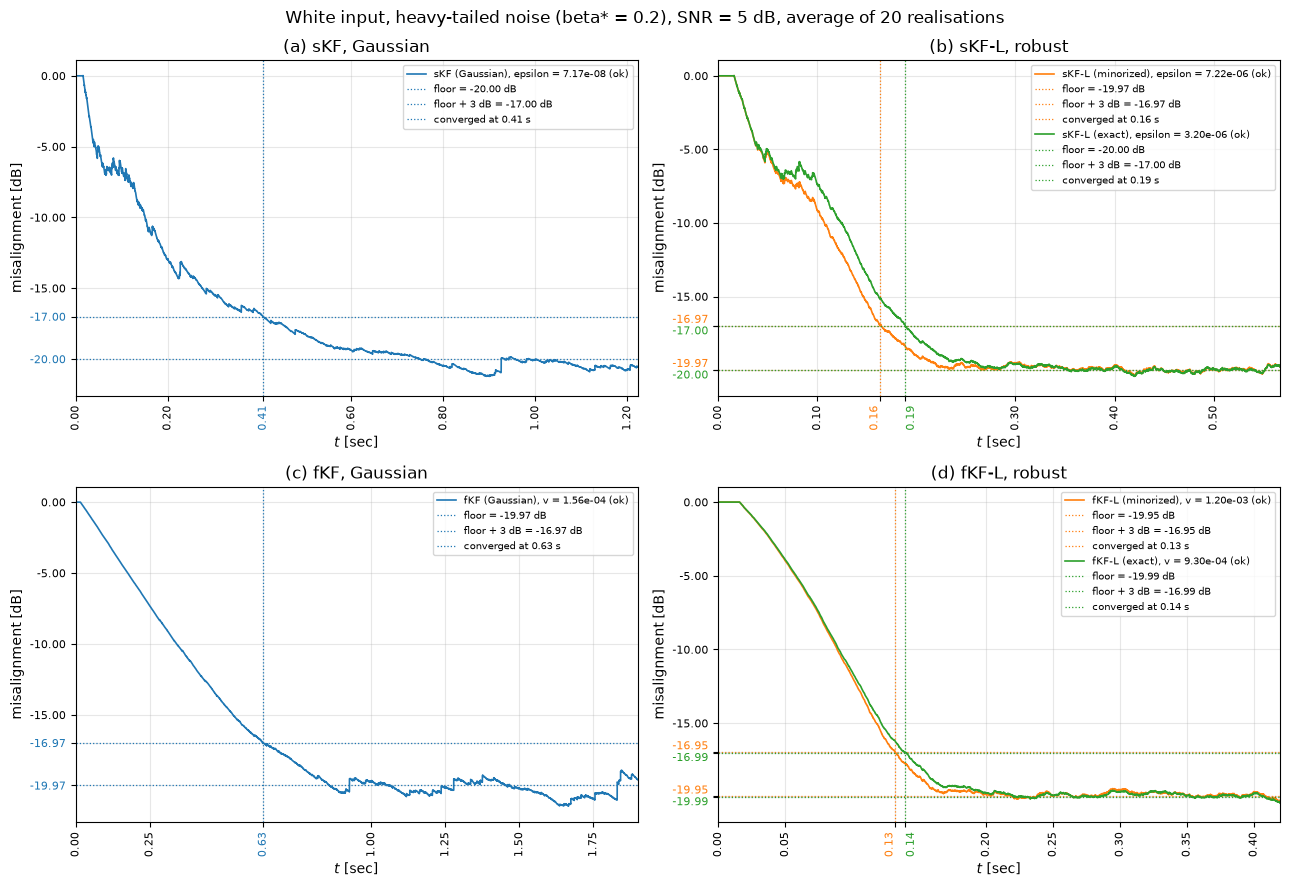

In [20]:
FIGURE1_TITLE = (f"White input, heavy-tailed noise (beta* = {BETA}), SNR = {SNR_DB:.0f} dB, "
                 f"average of {R} realisations")

def draw_curve(ax, result, name, swept_name, colour):
    """One curve, with its floor, its floor + 3 dB and its crossing instant dotted in its colour."""
    floor = float(result["floor"])
    reached = int(result["reached"])
    ax.plot(t_axis, 10*np.log10(result["misalignment"]), color=colour, linewidth=1.2,
            label=f"{name}, {swept_name} = {float(result['value']):.2e} ({result['status']})")
    ax.axhline(floor, color=colour, linestyle=":", linewidth=0.9,
               label=f"floor = {floor:.2f} dB")
    ax.axhline(floor + 3, color=colour, linestyle=":", linewidth=0.9,
               label=f"floor + 3 dB = {floor + 3:.2f} dB")
    ax.axvline(reached/FS, color=colour, linestyle=":", linewidth=0.9,
               label=f"converged at {reached/FS:.2f} s")
    return floor, reached


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
panels = [(axes[0][0], "(a) sKF, Gaussian",
           [("sKF (Gaussian)", resultado_skf_gauss, SWEPT_NAME_SKF, "C0")]),
          (axes[0][1], "(b) sKF-L, robust",
           [("sKF-L (minorized)", resultado_skf_min, SWEPT_NAME_SKF, "C1"),
            ("sKF-L (exact)", resultado_skf_exact, SWEPT_NAME_SKF, "C2")]),
          (axes[1][0], "(c) fKF, Gaussian",
           [("fKF (Gaussian)", resultado_fkf_gauss, SWEPT_NAME_FKF, "C0")]),
          (axes[1][1], "(d) fKF-L, robust",
           [("fKF-L (minorized)", resultado_fkf_min, SWEPT_NAME_FKF, "C1"),
            ("fKF-L (exact)", resultado_fkf_exact, SWEPT_NAME_FKF, "C2")])]

for ax, title, curves in panels:
    levels, colours_y, instants, colours_x = [], [], [], []
    slowest = 0
    for name, result, swept_name, colour in curves:
        floor, reached = draw_curve(ax, result, name, swept_name, colour)
        levels += [floor, floor + 3]
        colours_y += [colour, colour]
        instants.append(reached/FS)
        colours_x.append(colour)
        slowest = max(slowest, reached)
    ax.set_xlim(0, min(3*slowest, N)/FS)           # three times the slower convergence
    ax.set_title(title)
    ax.set_xlabel("$t$ [sec]")
    ax.set_ylabel("misalignment [dB]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")
    add_ticks(ax, "y", levels, colours_y, 2, 1.5)
    add_ticks(ax, "x", instants, colours_x, 2, 0.08*ax.get_xlim()[1])

fig.suptitle(FIGURE1_TITLE)
plt.tight_layout()
plt.show()

The selected runs. Floor: mean of the last quarter of the run. Converged: first step within 3 dB of that floor.

In [21]:
print(f"{'filter':<20}{'parameter':>11}{'floor [dB]':>12}{'steps':>9}{'time [s]':>10}  status")
for name, result, swept_name in RESULTS:
    value = float(result["value"])
    reached = int(result["reached"])
    value_text = "-" if np.isnan(value) else f"{value:.2e}"
    steps_text = "-" if reached < 0 else str(reached)
    time_text = "-" if reached < 0 else f"{reached/FS:.2f}"
    print(f"{name:<20}{value_text:>11}{float(result['floor']):>12.2f}{steps_text:>9}"
          f"{time_text:>10}  {result['status']}")

print()
for family, minorized, exact in [("sKF-L", RESULT_SKF_MIN, RESULT_SKF_EXACT),
                                 ("fKF-L", RESULT_FKF_MIN, RESULT_FKF_EXACT)]:
    steps_min, steps_exact = int(minorized["reached"]), int(exact["reached"])
    floor_min, floor_exact = float(minorized["floor"]), float(exact["floor"])
    if steps_min <= 0 or steps_exact <= 0:
        print(f"{family}, exact / minorized steps : one of the two never settled, no ratio")
        continue
    print(f"{family}, exact / minorized steps : {steps_exact}/{steps_min} = "
          f"{steps_exact/steps_min:.2f}x   (floors {floor_exact - floor_min:+.2f} dB apart)")

floors_all = []
for name, result, swept_name in RESULTS:
    floors_all.append(float(result["floor"]))
print(f"\nspread of the six floors      : {max(floors_all) - min(floors_all):.2f} dB")
print(f"target                        : {TARGET_DB:.1f} dB")

filter                parameter  floor [dB]    steps  time [s]  status
sKF (Gaussian)         7.17e-08      -20.00     3259      0.41  ok
sKF-L (minorized)      7.22e-06      -19.97     1307      0.16  ok
sKF-L (exact)          3.20e-06      -20.00     1512      0.19  ok
fKF (Gaussian)         1.56e-04      -19.97     5065      0.63  ok
fKF-L (minorized)      1.20e-03      -19.95     1058      0.13  ok
fKF-L (exact)          9.30e-04      -19.99     1119      0.14  ok

sKF-L, exact / minorized steps : 1512/1307 = 1.16x   (floors -0.03 dB apart)
fKF-L, exact / minorized steps : 1119/1058 = 1.06x   (floors -0.04 dB apart)

spread of the six floors      : 0.05 dB
target                        : -20.0 dB


**Figure 2.** Floor against time to converge, one point per settled value, minorized against exact **within each family**. **Lower and further left is better.** Stars: the runs of Figure 1. A curve below the other over the whole common range dominates: no choice of the parameter reverses it.

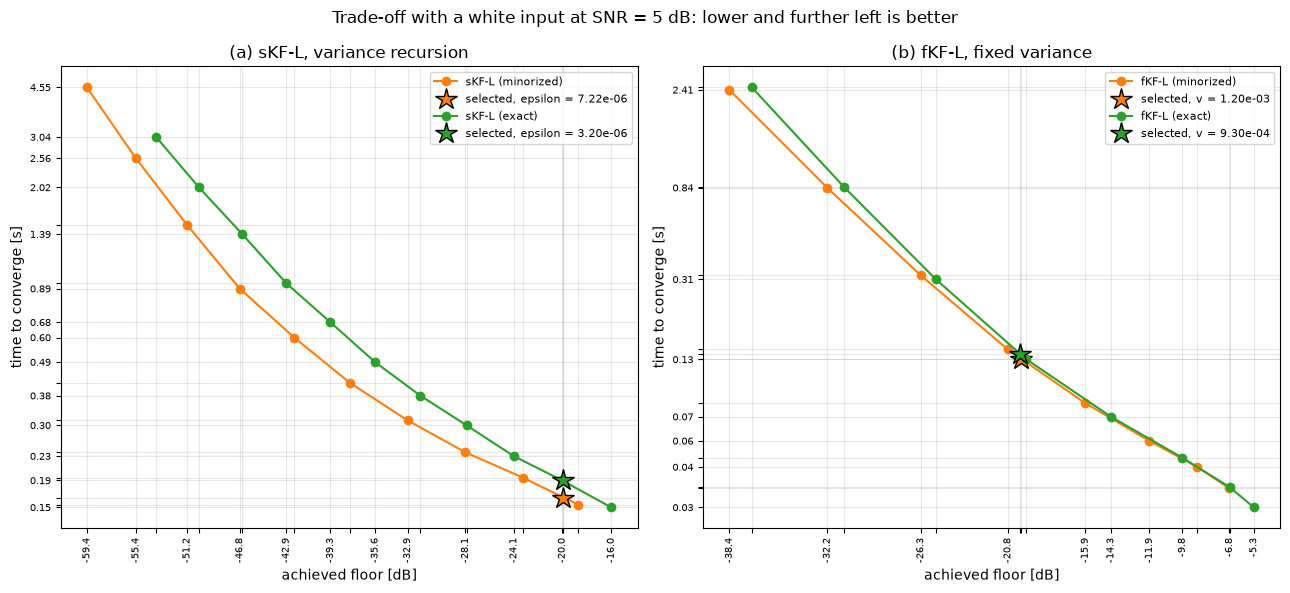

(a) sKF-L, variance recursion: common floor range -53.7 to -18.7 dB
   median separation between the curves: 37.0% of the minorized time
   no crossing: the exact filter needs more time at every floor in that range (by 172 to 7238 steps)
(b) fKF-L, fixed variance: common floor range -37.0 to -6.8 dB
   median separation between the curves: 8.1% of the minorized time
   the curves cross near floor [dB]: -14.2, -14.1
   read that against the separation above: many crossings at a separation of a
   few percent mean the two curves coincide, not that they trade places


In [22]:
FIGURE2_TITLE = f"Trade-off with a white input at SNR = {SNR_DB:.0f} dB: lower and further left is better"

SKF_L_TRADEOFF = [("sKF-L (minorized)", resultado_skf_min, SWEPT_NAME_SKF, "C1"),
                  ("sKF-L (exact)", resultado_skf_exact, SWEPT_NAME_SKF, "C2")]
FKF_L_TRADEOFF = [("fKF-L (minorized)", resultado_fkf_min, SWEPT_NAME_FKF, "C1"),
                  ("fKF-L (exact)", resultado_fkf_exact, SWEPT_NAME_FKF, "C2")]

fig, (ax_skf, ax_fkf) = plt.subplots(1, 2, figsize=(13, 6))
crossing_report = []

for ax, title, pair in [(ax_skf, "(a) sKF-L, variance recursion", SKF_L_TRADEOFF),
                        (ax_fkf, "(b) fKF-L, fixed variance", FKF_L_TRADEOFF)]:
    plotted = []
    star_floors, star_times = [], []                # the selected runs, off the grid
    for name, result, swept_name, colour in pair:
        keep = result["settled"]                   # unsettled points are out (section 4)
        floors, times = result["floors"][keep], result["steps"][keep]/FS
        plotted.append((name, floors, times))
        ax.plot(floors, times, "o-", color=colour, label=name)
        star_floors.append(float(result["floor"]))
        star_times.append(int(result["reached"])/FS)
        ax.plot(star_floors[-1], star_times[-1], "*", color=colour,
                markersize=16, markeredgecolor="k",
                label=f"selected, {swept_name} = {float(result['value']):.2e}")

    # Logarithmic in time, which spans decades, but with the times written out.
    # One tick per plotted point and per star, so every coordinate is read off the axis.
    ax.set_yscale("log")
    ax.minorticks_off()
    all_floors = np.concatenate([floors for _, floors, _ in plotted] + [np.array(star_floors)])
    all_times = np.concatenate([times for _, _, times in plotted] + [np.array(star_times)])
    ticks, labels = readable_ticks(all_floors, 0.045*np.ptp(all_floors), 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ticks, labels = readable_ticks(all_times, 0.035*np.ptp(np.log10(all_times)), 2, log=True)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("achieved floor [dB]")
    ax.set_ylabel("time to converge [s]")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    crossing_report.append((title, plotted))

fig.suptitle(FIGURE2_TITLE)
plt.tight_layout()
plt.show()

# Do the curves cross? Time of both at the same floor, over the floor range both cover.
for title, plotted in crossing_report:
    (name_min, floors_min, times_min), (name_ex, floors_ex, times_ex) = plotted
    common = np.linspace(max(floors_min.min(), floors_ex.min()),
                         min(floors_min.max(), floors_ex.max()), 200)
    gap = (np.interp(common, np.sort(floors_ex), times_ex[np.argsort(floors_ex)])
           - np.interp(common, np.sort(floors_min), times_min[np.argsort(floors_min)]))
    crossings = common[1:][np.diff(np.sign(gap)) != 0]
    reference = np.interp(common, np.sort(floors_min), times_min[np.argsort(floors_min)])
    separation = 100*np.median(np.abs(gap)/reference)   # how far apart the curves really are
    print(f"{title}: common floor range {common[0]:.1f} to {common[-1]:.1f} dB")
    print(f"   median separation between the curves: {separation:.1f}% of the minorized time")
    if crossings.size:
        print("   the curves cross near floor [dB]: " + ", ".join(f"{f:.1f}" for f in crossings))
        print("   read that against the separation above: many crossings at a separation of a")
        print("   few percent mean the two curves coincide, not that they trade places")
    else:
        slower = "exact" if gap.min() > 0 else "minorized"
        print(f"   no crossing: the {slower} filter needs more time at every floor in that range "
              f"(by {abs(gap).min()*FS:.0f} to {abs(gap).max()*FS:.0f} steps)")

**Figure 3.** The two robust pairs at four SNRs, each filter at the value its own search picked to land on the target: every point is a race at equal floor. The search is cheap, $R = 3$ over $N = 48000$ steps, and the curves are at $R = 10$.

In [23]:
SWEEP_SNR = [0.0, 5.0, 10.0, 15.0]     # the four SNRs, with the 5 dB of section 2 among them
R_SEARCH = 3                # realisations while scanning the grid at each SNR
R_PLOT = 10                 # realisations for the curves tabulated below
N_SWEEP = 48000             # 6 s at 8 kHz: enough, both robust pairs converge in a few thousand steps
SNR_CACHE = CACHE_PREFIX + "snr_sweep.npz"

# Changing the SNR moves the floors a filter can reach, so the grids of section 4 stop
# covering the target at the ends of the sweep. These are wider and coarser: one point per
# decade over eight and six decades, at the same two points per decade as section 4.
EPS_GRID_SNR = np.logspace(-11, -3, 17)
V_GRID_SNR = np.logspace(-6, 0, 13)

# The four robust filters. Each row of the tables below is one of these, in this order.
ROBUST = [("sKF-L (minorized)", sKF_L_minorized, SWEPT_NAME_SKF, EPS_GRID_SNR),
          ("sKF-L (exact)", sKF_L_exact, SWEPT_NAME_SKF, EPS_GRID_SNR),
          ("fKF-L (minorized)", fKF_L_minorized, SWEPT_NAME_FKF, V_GRID_SNR),
          ("fKF-L (exact)", fKF_L_exact, SWEPT_NAME_FKF, V_GRID_SNR)]


def search_at_snr(filter_function, swept_name, grid, fixed_parameters, signals_search, signals_plot):
    """Scan the grid cheaply at the current SNR, pick the value that lands on the target, run it."""
    floors = np.zeros(len(grid))
    settled = np.zeros(len(grid), dtype=bool)
    for i in range(len(grid)):
        parameters = fixed_parameters.copy()
        parameters[swept_name] = grid[i]
        misalignment = run_filter(filter_function, parameters, N_SWEEP, signals_search)
        floors[i] = steady_state(misalignment)[0]
        settled[i] = is_settled(misalignment)

    if not settled.any():
        return {"value": np.nan, "floor": np.nan, "steps": -1, "best": np.nan}
    settled_values, settled_floors = grid[settled], floors[settled]
    if TARGET_DB < settled_floors.min() or TARGET_DB > settled_floors.max():
        # The target is outside the floors this grid reaches at this SNR. The deepest
        # settled floor says whether the grid is short or the filter simply cannot go there.
        return {"value": np.nan, "floor": np.nan, "steps": -1, "best": settled_floors.min()}

    order = np.argsort(settled_floors)
    value = 10**np.interp(TARGET_DB, settled_floors[order], np.log10(settled_values)[order])
    parameters = fixed_parameters.copy()
    parameters[swept_name] = value
    misalignment = run_filter(filter_function, parameters, N_SWEEP, signals_plot)
    floor, reached = steady_state(misalignment)
    return {"value": value, "floor": floor, "steps": reached, "best": settled_floors.min()}


# One row per SNR, one column per filter of ROBUST, in that order.
if os.path.exists(SNR_CACHE):
    with np.load(SNR_CACHE) as stored:
        snr_values, snr_floors, snr_steps = stored["values"], stored["floors"], stored["steps"]
        snr_best = stored["best"]
    print(f"SNR sweep loaded from {SNR_CACHE}")
else:
    print(f"computing the SNR sweep at {len(SWEEP_SNR)} SNRs, R = {R_SEARCH} while scanning")
    start = time.time()
    snr_values = np.zeros((len(SWEEP_SNR), len(ROBUST)))
    snr_floors = np.zeros((len(SWEEP_SNR), len(ROBUST)))
    snr_steps = np.zeros((len(SWEEP_SNR), len(ROBUST)), dtype=int)
    snr_best = np.zeros((len(SWEEP_SNR), len(ROBUST)))

    for row in range(len(SWEEP_SNR)):
        # generate_signals reads scale_gg off the globals, and the filters read var_eta and
        # b_eta, so this loop reassigns the three and puts them back afterwards.
        var_eta = P_signal/10**(SWEEP_SNR[row]/10)
        b_eta = np.sqrt(var_eta/2)
        scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))
        parameters_skf = {"b_eta": b_eta, "var_theta_0": VAR_THETA_0}
        parameters_fkf = {"b_eta": b_eta}

        signals_search = []
        for seed in range(R_SEARCH):
            x, d, eta = generate_signals(seed)
            signals_search.append((x, d))
        signals_plot = []
        for seed in range(R_PLOT):
            x, d, eta = generate_signals(seed)
            signals_plot.append((x, d))

        for column in range(len(ROBUST)):
            name, filter_function, swept_name, grid = ROBUST[column]
            fixed = parameters_skf if swept_name == SWEPT_NAME_SKF else parameters_fkf
            found = search_at_snr(filter_function, swept_name, grid, fixed,
                                  signals_search, signals_plot)
            snr_values[row, column] = found["value"]
            snr_floors[row, column] = found["floor"]
            snr_steps[row, column] = found["steps"]
            snr_best[row, column] = found["best"]
        print(f"   SNR {SWEEP_SNR[row]:.0f} dB done   [{time.time() - start:.0f} s]")

    var_eta = P_signal/10**(SNR_DB/10)     # back to the scenario of section 2
    b_eta = np.sqrt(var_eta/2)
    scale_gg = np.sqrt(var_eta/np.exp(gammaln(3/BETA) - gammaln(1/BETA)))
    np.savez(SNR_CACHE, values=snr_values, floors=snr_floors, steps=snr_steps, best=snr_best)
    print(f"SNR sweep done in {(time.time() - start)/60:.1f} min, saved to {SNR_CACHE}")
    print(f"var_eta back to {var_eta:.4e}, the value section 2 printed")

SNR sweep loaded from ../cache/05_blanca_snr_sweep.npz


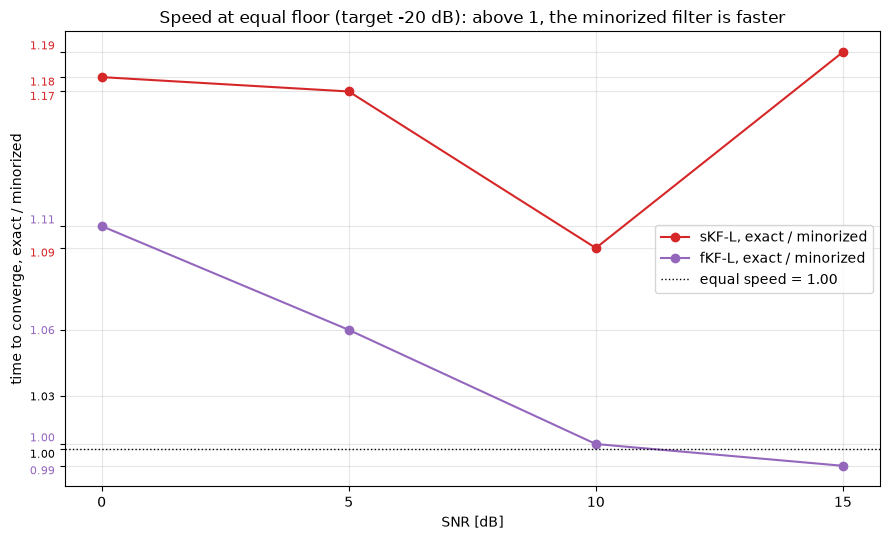

  SNR  filter                parameter  floor [dB]    steps  time [s]
    0  sKF-L (minorized)      6.79e-06      -19.92     1525      0.19
    0  sKF-L (exact)          2.46e-06      -19.94     1792      0.22
    0  fKF-L (minorized)      1.33e-03      -19.90     1419      0.18
    0  fKF-L (exact)          1.09e-03      -19.94     1568      0.20
    5  sKF-L (minorized)      7.35e-06      -19.90     1307      0.16
    5  sKF-L (exact)          3.25e-06      -19.96     1527      0.19
    5  fKF-L (minorized)      1.22e-03      -19.89     1068      0.13
    5  fKF-L (exact)          9.40e-04      -19.96     1128      0.14
   10  sKF-L (minorized)      8.89e-06      -19.88     1183      0.15
   10  sKF-L (exact)          4.29e-06      -19.91     1295      0.16
   10  fKF-L (minorized)      1.32e-03      -19.82      805      0.10
   10  fKF-L (exact)          8.71e-04      -19.91      807      0.10
   15  sKF-L (minorized)      1.59e-05      -19.69      915      0.11
   15  sKF-L (exact)

In [24]:
# Ratio of times at equal floor, one curve per family. Columns 0 and 1 are the sKF-L pair,
# columns 2 and 3 the fKF-L pair, in the order of ROBUST.
fig, ax = plt.subplots(figsize=(9, 5.5))
levels, colours_y = [1.0], ["k"]
missing = []
for family, minorized_column, exact_column, colour in [("sKF-L", 0, 1, "C3"),
                                                       ("fKF-L", 2, 3, "C4")]:
    # An SNR where either filter missed the target has no ratio to plot: it is left out
    # of the curve and listed under the figure.
    snr_kept, ratio = [], []
    for row in range(len(SWEEP_SNR)):
        steps_minorized = snr_steps[row, minorized_column]
        steps_exact = snr_steps[row, exact_column]
        if steps_minorized > 0 and steps_exact > 0:
            snr_kept.append(SWEEP_SNR[row])
            ratio.append(steps_exact/steps_minorized)
        else:
            missing.append(f"{family} at {SWEEP_SNR[row]:.0f} dB")
    ax.plot(snr_kept, ratio, "o-", color=colour, label=f"{family}, exact / minorized")
    levels += ratio
    colours_y += [colour]*len(ratio)

ax.axhline(1.0, color="k", linestyle=":", linewidth=1.0, label="equal speed = 1.00")
ax.set_xticks(SWEEP_SNR)                           # exactly the swept values
ax.set_xlabel("SNR [dB]")
ax.set_ylabel("time to converge, exact / minorized")
ax.set_title(f"Speed at equal floor (target {TARGET_DB:.0f} dB): above 1, the minorized filter is faster")
ax.legend()
ax.grid(alpha=0.3)
add_ticks(ax, "y", levels, colours_y, 2, 0.02)
plt.tight_layout()
plt.show()

print(f"{'SNR':>5}  {'filter':<20}{'parameter':>11}{'floor [dB]':>12}{'steps':>9}{'time [s]':>10}")
for row in range(len(SWEEP_SNR)):
    for column in range(len(ROBUST)):
        name = ROBUST[column][0]
        value, floor, steps = snr_values[row, column], snr_floors[row, column], snr_steps[row, column]
        value_text = "-" if np.isnan(value) else f"{value:.2e}"
        steps_text = "-" if steps < 0 else str(steps)
        time_text = "-" if steps < 0 else f"{steps/FS:.2f}"
        note = "" if steps > 0 else f"  deepest settled floor {snr_best[row, column]:+.2f} dB"
        print(f"{SWEEP_SNR[row]:>5.0f}  {name:<20}{value_text:>11}{floor:>12.2f}"
              f"{steps_text:>9}{time_text:>10}{note}")

print()
if missing:
    print("   no ratio at: " + ", ".join(missing))
    print("   at those SNRs the target sits outside the floors the grid reaches, so the")
    print("   interpolation has nothing to land on and the point is left out of the figure.")
    print("   Compare the target with the deepest settled floor printed on each of those rows:")
    print("   if that floor is above the target, no value of the parameter gets there at all.")
print("   the search here is cheap (R = 3 over N = 48000) and the curves are at R = 10, so")
print("   these floors and steps are noisier than the ones of Figure 1; the ratio is what matters")
print(f"\nwhole notebook: {(time.time() - NOTEBOOK_START)/60:.1f} min")